## Customer Retention Analysis by Cohort: Repeat Purchases Over Time

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mysql.connector

In [88]:
# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='alt_mobility',
)
cursor = conn.cursor()

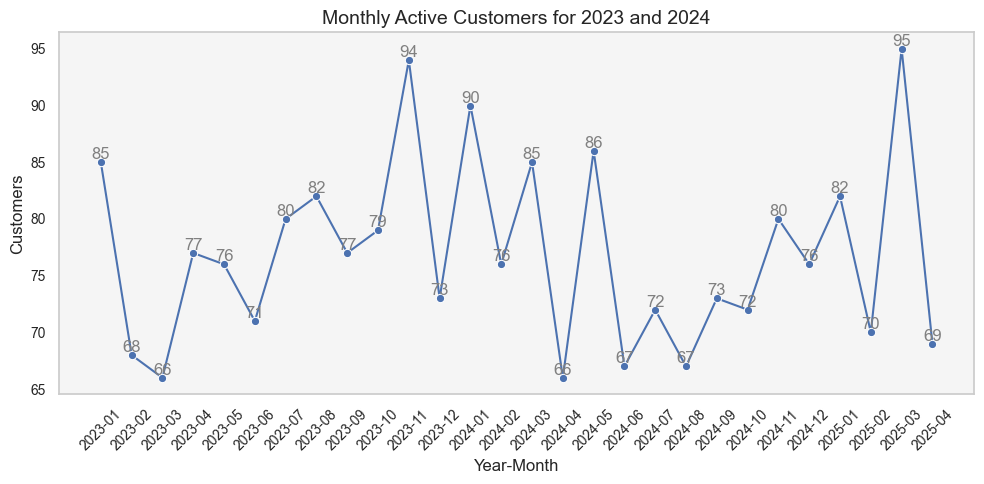

In [79]:
query1 = """
SELECT 
    EXTRACT(YEAR FROM order_date) AS year,
    EXTRACT(MONTH FROM order_date) AS month,
    COUNT(DISTINCT customer_id) AS active_customers,
    COUNT(*) AS total_orders
FROM customer_orders
WHERE order_status = 'delivered'
GROUP BY year, month
ORDER BY year, month;
"""

cursor.execute(query1)
rows = cursor.fetchall()

df1 = pd.DataFrame(rows, columns=['year', 'month', 'active_customers', 'total_orders'])
df1["year_month"] = df1["year"].astype(str) + "-" + df1["month"].astype(str).str.zfill(2)

# Filter data for a specific year (2023)
selected_year = 2023
df_filtered = df1[df1['year'] >= selected_year]

# Plotting using seaborn
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_filtered, x="year_month", y="active_customers", marker='o')

# Annotate each point with its y-value (active_customers)
for i in range(len(df_filtered)):
    plt.text(x=df_filtered["year_month"].iloc[i], 
             y=df_filtered["active_customers"].iloc[i], 
             s=str(df_filtered["active_customers"].iloc[i]), 
             ha='center', va='bottom', fontsize=12, color='grey')

# Adjust font size for labels
plt.xticks(rotation=45, fontsize=10)  
plt.xlabel("Year-Month", fontsize=12) 
plt.ylabel("Customers", fontsize=12)
plt.yticks(fontsize=10)
plt.gca().set_facecolor('#F5F5F5')  # Set axes' background to white (or any color you prefer)
plt.grid(False) # Remove grid

plt.title("Monthly Active Customers for 2023 and 2024", fontsize=14)
plt.xlabel("Year-Month")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()


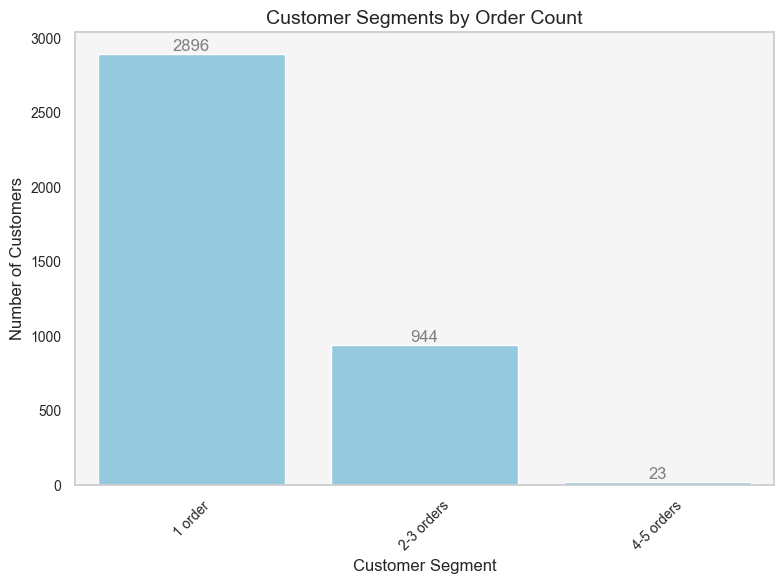

In [80]:
query2 = """
WITH customer_stats AS (
    SELECT 
        customer_id,
        COUNT(*) AS order_count,
        SUM(order_amount) AS total_spent,
        AVG(order_amount) AS average_order_value,
        EXTRACT(DAY FROM MAX(order_date) - MIN(order_date)) AS customer_lifetime_days
    FROM customer_orders
    WHERE order_status = 'delivered'
    GROUP BY customer_id
)

SELECT 
    CASE 
        WHEN order_count = 1 THEN '1 order'
        WHEN order_count BETWEEN 2 AND 3 THEN '2-3 orders'
        WHEN order_count BETWEEN 4 AND 5 THEN '4-5 orders'
        ELSE '6+ orders'
    END AS customer_segment,
    COUNT(*) AS customer_count,
    ROUND(AVG(total_spent), 2) AS avg_total_spent,
    ROUND(AVG(average_order_value), 2) AS avg_order_value,
    ROUND(AVG(customer_lifetime_days), 0) AS avg_lifetime_days
FROM customer_stats
GROUP BY customer_segment
"""

cursor.execute(query2)
rows = cursor.fetchall()

df2 = pd.DataFrame(rows, columns=["customer_segment", "customer_count", "avg_total_spent", "avg_order_value", "avg_lifetime_days"])

# Create the seaborn bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x="customer_segment", y="customer_count", data=df2, color='skyblue')

# label
for i in range(len(df2)):
    plt.text(x=df2["customer_segment"].iloc[i], 
             y=df2["customer_count"].iloc[i], 
             s=str(df2["customer_count"].iloc[i]), 
             ha='center', va='bottom', fontsize=12, color='grey')

# Adjust font size for labels
plt.xticks(rotation=45, fontsize=10)  
plt.yticks(fontsize=10)
plt.gca().set_facecolor('#F5F5F5')  # Set axes' background to white (or any color you prefer)
plt.grid(False) # Remove grid

# Title and labels
plt.title("Customer Segments by Order Count", fontsize=14)
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()



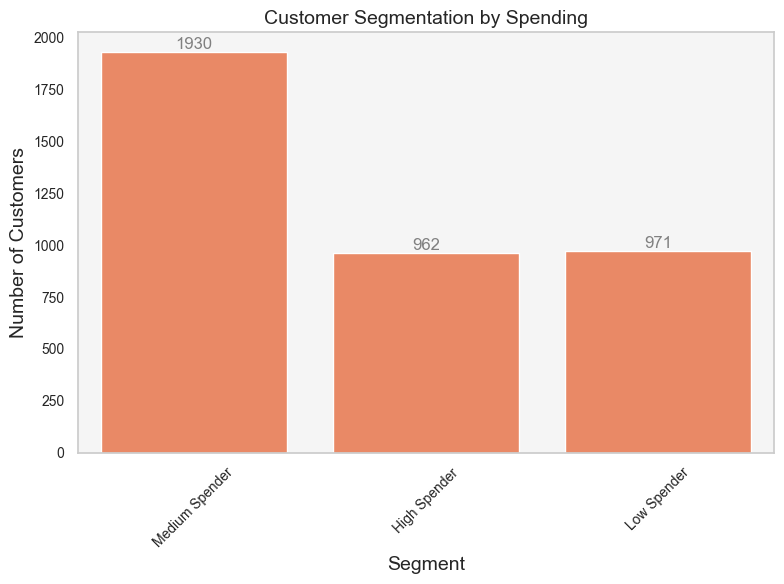

In [81]:
query3 = """
WITH customer_stats AS (
    SELECT 
        customer_id,
        SUM(order_amount) AS total_spend
    FROM customer_orders
    WHERE order_status = 'delivered'
    GROUP BY customer_id
)
SELECT 
    CASE 
        WHEN total_spend >= 448 THEN 'High Spender'
        WHEN total_spend BETWEEN 170 AND 447 THEN 'Medium Spender'
        ELSE 'Low Spender'
    END AS segment,
    COUNT(*) AS customers,
    ROUND(AVG(total_spend), 2) AS avg_spend,
    ROUND(SUM(total_spend), 2) AS total_revenue
FROM customer_stats
GROUP BY segment
ORDER BY total_revenue DESC;
"""

cursor.execute(query3)
rows = cursor.fetchall()

df = pd.DataFrame(rows, columns=["segment", "customers", "avg_spend", "total_revenue"])

# Visualization
plt.figure(figsize=(8, 6))
sns.barplot(x="segment", y="customers", data=df, color='coral')

# label
for i in range(len(df)):
    plt.text(x=df["segment"].iloc[i], 
             y=df["customers"].iloc[i], 
             s=str(df["customers"].iloc[i]), 
             ha='center', va='bottom', fontsize=12, color='grey')

# Adjust font size for labels
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.gca().set_facecolor('#F5F5F5')  # Set axes' background to white (or any color you prefer)
plt.grid(False) # Remove grid

plt.title("Customer Segmentation by Spending", fontsize=14)
plt.xlabel("Segment", fontsize=14)
plt.ylabel("Number of Customers", fontsize=14)
plt.tight_layout()
plt.show()


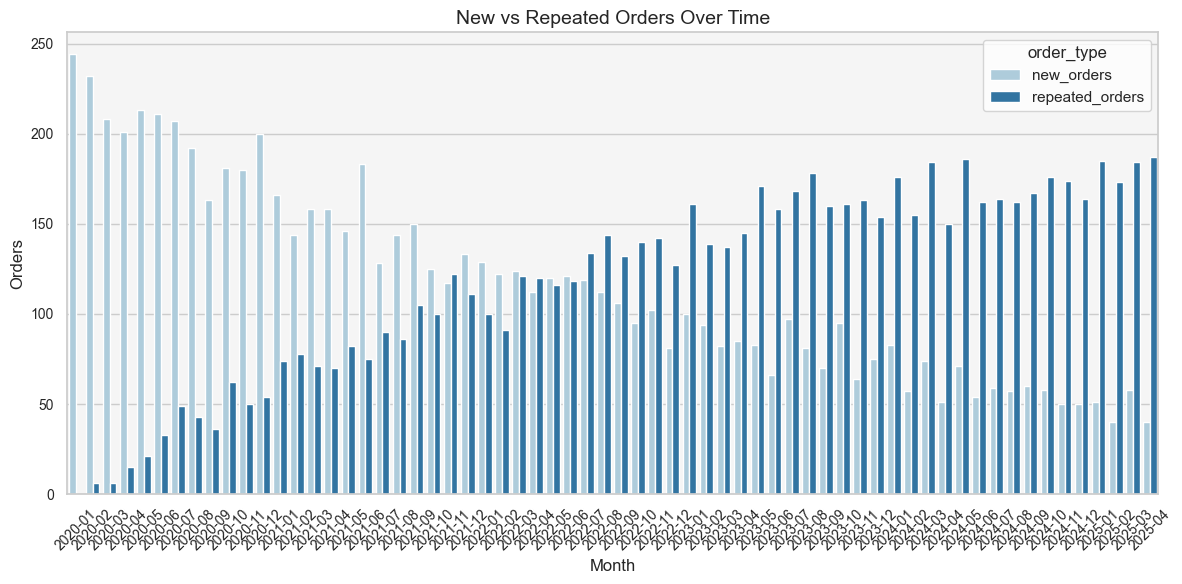

In [85]:
query4 = """
WITH first_order_date AS (
    SELECT 
        customer_id, 
        MIN(order_date) AS first_order_date
    FROM customer_orders
    GROUP BY customer_id
),
orders_with_flags AS (
    SELECT 
        o.order_id,
        o.customer_id,
        o.order_date,
        DATE_FORMAT(o.order_date, '%Y-%m') AS order_year_month,
        CASE 
            WHEN DATE_FORMAT(o.order_date, '%Y-%m') = DATE_FORMAT(f.first_order_date, '%Y-%m') THEN 'New'
            ELSE 'Repeated'
        END AS order_type
    FROM customer_orders o
    JOIN first_order_date f ON o.customer_id = f.customer_id
)
SELECT 
    order_year_month,
    COUNT(CASE WHEN order_type = 'New' THEN 1 END) AS new_orders,
    COUNT(CASE WHEN order_type = 'Repeated' THEN 1 END) AS repeated_orders
FROM orders_with_flags
GROUP BY order_year_month
ORDER BY order_year_month;
"""

cursor.execute(query4)
rows = cursor.fetchall()

df = pd.DataFrame(rows, columns=["order_year_month", "new_orders", "repeated_orders"])

df_melted = df.melt(id_vars="order_year_month", value_vars=["new_orders", "repeated_orders"], var_name="order_type", value_name="order_count")

plt.figure(figsize=(12, 6))
sns.barplot(x="order_year_month", y="order_count", hue="order_type", data=df_melted, palette="Paired")

# Title and labels
plt.title("New vs Repeated Orders Over Time", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Orders", fontsize=12)

# Adjust x-ticks
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Set background color
plt.gca().set_facecolor('#F5F5F5')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()




In [83]:
df5

,cohort_start_month,y0,y1,y2,y3,y4_plus
24,2022-01,100.0,9.0,10.0,11.0,4.0
25,2022-02,100.0,10.0,5.0,14.0,2.0
26,2022-03,100.0,16.0,14.0,9.0,0.0
27,2022-04,100.0,15.0,8.0,10.0,0.0
28,2022-05,100.0,10.0,3.0,12.0,0.0
29,2022-06,100.0,9.0,7.0,9.0,0.0
30,2022-07,100.0,10.0,11.0,9.0,0.0
31,2022-08,100.0,11.0,11.0,4.0,0.0
32,2022-09,100.0,3.0,7.0,5.0,0.0
33,2022-10,100.0,7.0,11.0,9.0,0.0


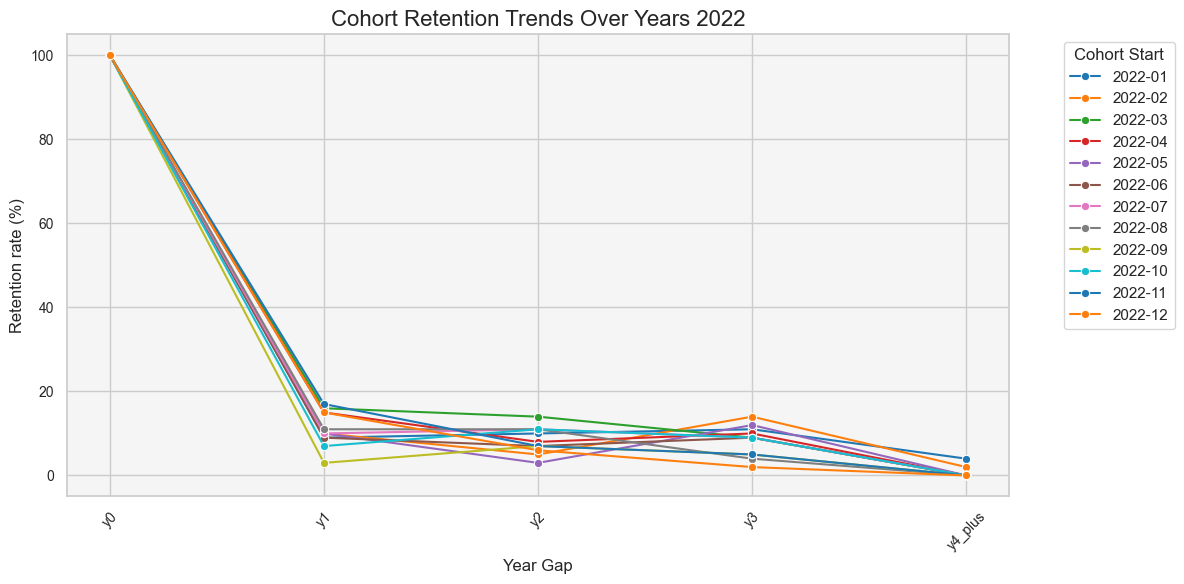

In [86]:
# Query: Cohort retention over years
query5 = """
WITH customer_first_order AS (
    SELECT 
        customer_id,
        DATE_FORMAT(MIN(order_date), '%Y-%m') AS cohort_year_month 
    FROM customer_orders
    WHERE order_status = 'delivered'
    GROUP BY customer_id
),
cohort_data AS (
    SELECT 
        cfo.cohort_year_month,
        co.order_id,
        co.customer_id,
        co.order_date,
        DATE_FORMAT(co.order_date, '%Y-%m') AS order_month,
        TIMESTAMPDIFF(
            MONTH,
            STR_TO_DATE(CONCAT(cfo.cohort_year_month, '-01'), '%Y-%m-%d'),
            DATE(co.order_date)
        ) AS months_since_first_order
    FROM customer_orders co
    JOIN customer_first_order cfo ON co.customer_id = cfo.customer_id
    WHERE order_status = 'delivered'
),
cohort_table AS (
    SELECT 
        cohort_year_month AS cohort_start_month,
        COUNT(DISTINCT CASE WHEN months_since_first_order = 0 THEN customer_id END) AS cohort_size,
        COUNT(DISTINCT CASE WHEN months_since_first_order BETWEEN 1 AND 12 THEN customer_id END) AS year_1,
        COUNT(DISTINCT CASE WHEN months_since_first_order BETWEEN 13 AND 24 THEN customer_id END) AS year_2,
        COUNT(DISTINCT CASE WHEN months_since_first_order BETWEEN 25 AND 36 THEN customer_id END) AS year_3,
        COUNT(DISTINCT CASE WHEN months_since_first_order > 36 THEN customer_id END) AS year_4_plus
    FROM cohort_data
    GROUP BY cohort_year_month
)
SELECT
    cohort_start_month,
    ROUND((cohort_size / CAST(cohort_size AS DECIMAL)) * 100, 0) AS y0,
    ROUND((year_1 / CAST(cohort_size AS DECIMAL)) * 100, 0) AS y1,
    ROUND((year_2 / CAST(cohort_size AS DECIMAL)) * 100, 0) AS y2,
    ROUND((year_3 / CAST(cohort_size AS DECIMAL)) * 100, 0) AS y3,
    ROUND((year_4_plus / CAST(cohort_size AS DECIMAL)) * 100, 0) AS y4_plus
FROM cohort_table;
"""

cursor.execute(query5)
rows = cursor.fetchall()

df5 = pd.DataFrame(rows, columns=["cohort_start_month", "y0", "y1", "y2", "y3", "y4_plus"])

df5['cohort_start_month'] = pd.to_datetime(df5['cohort_start_month'], format='%Y-%m')

selected_year = 2022
df5 = df5[df5['cohort_start_month'].dt.year == selected_year]

df5 = df5.sort_values('cohort_start_month')

df5['cohort_start_month'] = df5['cohort_start_month'].dt.strftime('%Y-%m')

retention_cols = ['y0', 'y1', 'y2', 'y3', 'y4_plus']
df5[retention_cols] = df5[retention_cols].apply(pd.to_numeric, errors='coerce')

df5_melted = df5.melt(
    id_vars='cohort_start_month',
    var_name='year_bucket',
    value_name='retention'
)

year_order = ['y0', 'y1', 'y2', 'y3', 'y4_plus']
df5_melted['year_bucket'] = pd.Categorical(df5_melted['year_bucket'], categories=year_order, ordered=True)

# Plot
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

sns.lineplot(
    data=df5_melted,
    x="year_bucket",
    y="retention",
    hue="cohort_start_month",
    marker="o",
    palette="tab10"
)

plt.title(f"Cohort Retention Trends Over Years {selected_year}", fontsize=16)
plt.xlabel("Year Gap", fontsize=12)
plt.ylabel("Retention rate (%)", fontsize=12)
plt.legend(title="Cohort Start", bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust font size for labels
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.gca().set_facecolor('#F5F5F5')  # Set axes' background to white (or any color you prefer)

plt.tight_layout()
plt.show()
